In [ ]:
# import numpy as np
# import scipy as sp
# import matplotlib.pyplot as plt
# from itertools import combinations

# %load_ext autoreload
# %autoreload 2
# %matplotlib widget
# import matplotlib.pyplot as plt

# plt.rcParams.update({'font.size': 8})
# plt.rcParams.update({'pdf.fonttype':42})
# plt.rcParams.update({'figure.max_open_warning': 0})
# plt.rcParams['axes.spines.right'] = False
# plt.rcParams['axes.spines.top'] = False


# better_result=dict(x=np.load('/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/de_fitting_hcpmeg_subc_dti50_4.npy'))

# Laplacian_eigenvalues = np.load('/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/eigvals_DTI_fgCCfix_subcortex_dti50.npy')


# def GraphKernel(x,t,type='Gaussian', a=10**3, b=10, c=0, prime=False):
#     if t<0:
#         #print("Need positive kernel parameter")
#         return
#     else:
#         if type=='Gaussian':
#             #add prefactor to make kernel of unitary height
#             return np.exp(t*x)#*2*np.sqrt(t*np.pi)
#         elif type=='Exponential':
#             return t/(t-x) #*2*t
#         elif type=='Pyramid':
#             #return t*(np.sinc(t*np.sqrt(-x)/(2*np.pi)))**2
#             return np.sinc(np.sqrt(-x)/(2*np.pi*t))**2
#         elif type=='Rectangle':
#             #Note: significant Gibbs effect makes this not advisable
#             rect=np.sinc(np.sqrt(-x)/(2*np.pi*t))
#             #rect[-990:]=0
#             return rect
#         elif type=='Mexican Hat':
#             return -x*np.exp(t*x) #*2*np.sqrt(t*np.pi)  #*2*t
#         elif type=='Damped Wave':
#             delta_dw = b**2 + 4*a*(x-c)
#             if a>0:# and np.all((delta_dw >=0)):

#                 r_1=(-b+np.emath.sqrt(delta_dw))/(2*a)
#                 r_2=(-b-np.emath.sqrt(delta_dw))/(2*a)
#                 rdiff = r_1-r_2
#                 #print(rdiff.imag)
#                 if np.all(rdiff != 0):


#                     Damped_Wave_Kernel=(r_1*np.exp(r_2*t)-r_2*np.exp(r_1*t))/(rdiff)

#                     if prime:
#                         Damped_Wave_Kernel_prime=(np.exp(r_1*t)-np.exp(r_2*t))/(rdiff)

#                         return Damped_Wave_Kernel.real.astype('float64'), Damped_Wave_Kernel_prime.real.astype('float64')
#                     else:
#                         return Damped_Wave_Kernel.real.astype('float64')
#                 else:
#                     print('lol')
#                     return np.nan
#             else:
#                 print('lolaaa')
#                 return np.nan

# def H_Simple_Steady_State(alpha_EE=1, alpha_IE=1, alpha_EI=1, alpha_II=1, d_e=1, d_i=1, P=0, Q=0):
#     #generate multiple initial conditions to find all steady states
#     initial_guesses = 20
#     ##print("%.3g %.3g %.3g %.3g %.3g %.3g %.3g %.3g"%(alpha_EE, alpha_IE, alpha_EI, alpha_II, d_e, d_i, P, Q))

#     # x0 = np.zeros((2,initial_guesses))
#     # x0[:,1] = np.array([1/(2*d_e), 1/(2*d_i)])
#     # x0[:,2] = np.random.rand(2)
#     # x0[:,3] = np.random.rand(2)
#     # x0[:,4] = np.random.rand(2)

#     x0 = np.random.rand(2,initial_guesses)
#     results = []

#     success = False

#     def f(x, alpha_EE, alpha_IE, alpha_EI, alpha_II, d_e, d_i, P, Q):
#         d = np.array([[d_e,0],[0,d_i]], dtype=float)
#         alpha = np.array([[alpha_EE,-alpha_IE],[alpha_EI,-alpha_II]], dtype=float)
#         X = np.array([P,Q], dtype=float)

#         SS_EQ = - np.dot(d,x) + sp.special.expit(np.dot(alpha,x) + X)
#         return SS_EQ

#     for i in range(initial_guesses):
#         steady_state_res = sp.optimize.root(f,x0[:,i],args=(alpha_EE,alpha_IE,alpha_EI,alpha_II,d_e,d_i,P,Q),
#                                           method='lm',
#                                           options={'ftol':1e-12})
#         #print(steady_state_res['x'])
#         #print(steady_state_res['fun'][0]-steady_state_res['fun'][1])
#         fun = steady_state_res['fun'][0]-steady_state_res['fun'][1]
#         steady_state = steady_state_res['x']


#         if np.all(steady_state>0.001) and np.all(steady_state<0.999) and np.abs(fun) <1e-9: # and np.linalg.norm(steady_state[1]['fvec'],ord=1)<=1e-20:
#             results.append(steady_state)
#             success=True


#     #select and importantly sort the unique, acceptable results
#     if success==True:
#         results = np.array(results)
#         #print(np.unique(results.round(5), axis=0, return_index=True))
#         #results = results[:,~np.all(np.isnan(results), axis=0)]

#         finals = results[np.unique(results.round(5), axis=0, return_index=True)[1]]

#         return finals.T, success
#     else:
#   #      #print("No positive, exact solutions were found")
#         return None, success


# # -----------------------
# # Placeholder for Jacobian computation
# # -----------------------
# def compute_jacobian(params, ss):
#     """
#     Compute the Jacobian matrix for the Wilson-Cowan model at the fixed point.
#     Parameters:
#         params (dict): Dictionary of model parameters.
#     Returns:
#         J (np.ndarray): Jacobian matrix (40,000 x 40,000 for 20,000 nodes with E/I).
#     """
#     Graph_Kernel = 'Damped Wave'

#     aEE = params['aEE']
#     aIE = params['aIE']
#     aEI = params['aEI']
#     aII = params['aII']
#     dE = params['dE']
#     dI = params['dI']
#     P = params['P']
#     Q = params['Q']
#     sEE = params['sEE']
#     sIE = params['sIE']
#     sEI = params['sEI']
#     sII = params['sII']
#     tE = params['tE']
#     tI = params['tI']
#     aDWEE = params['aDWEE']
#     aDWIE = params['aDWIE']
#     aDWEI = params['aDWEI']
#     aDWII = params['aDWII']
#     bDWEE = params['bDWEE']
#     bDWIE = params['bDWIE']
#     bDWEI = params['bDWEI']
#     bDWII = params['bDWII']

#     t_EE = (0.5*sEE**2)
#     t_IE = (0.5*sIE**2)
#     t_EI = (0.5*sEI**2)
#     t_II = (0.5*sII**2)

#     eigs=Laplacian_eigenvalues

#     Jacobian_eigenvalues=np.zeros((len(eigs),2),dtype=complex)

#     Ess = ss[0]
#     Iss = ss[1]

#     ass = dE*Ess*(1-dE*Ess)
#     bss = dI*Iss*(1-dI*Iss)

#     K_EE = GraphKernel(eigs,t_EE,type=Graph_Kernel,a=aDWEE,b=bDWEE)
#     K_IE = GraphKernel(eigs,t_IE,type=Graph_Kernel,a=aDWIE,b=bDWIE)
#     K_EI = GraphKernel(eigs,t_EI,type=Graph_Kernel,a=aDWEI,b=bDWEI)
#     K_II = GraphKernel(eigs,t_II,type=Graph_Kernel,a=aDWII,b=bDWII)

#     return np.array([[-dE/tE + aEE*ass*K_EE/tE, -aIE*ass*K_IE/tE],[aEI*bss*K_EI/tI,-dI/tI -aII*bss*K_II/tI]]).T

# def leading_eigenvalue(jacobian):
#     """
#     Compute the leading eigenvalue (largest real part) of the Jacobian.
#     """
#     eigvals_real = np.ravel(np.linalg.eigvals(jacobian)).real
#     return np.max(eigvals_real)


# # -----------------------
# # Sensitivity Analysis to Identify Relevant Parameters
# # -----------------------
# def sensitivity_analysis(params, perturbation_scales=[0.01, 0.02], max_attempts=3, threshold=0.1):
#     """
#     Identify parameters that significantly affect stability using a staircase approach.
#     Parameters:
#         params (dict): Model parameters.
#         perturbation_scales (list): Initial perturbation scales (e.g., 1%, 2%).
#         max_attempts (int): Max number of refinement steps per parameter.
#         threshold (float): Change in Re(λ_max) to consider parameter sensitive.
#     Returns:
#         sensitive_params (list): List of parameter names that affect stability.
#     """
#     sensitive_params = []
#     # Compute steady states for base parameters
#     steady_states, success = H_Simple_Steady_State(
#         alpha_EE=params['aEE'], alpha_IE=params['aIE'], alpha_EI=params['aEI'], alpha_II=params['aII'],
#         d_e=params['dE'], d_i=params['dI'], P=params['P'], Q=params['Q']
#     )
#     if not success or steady_states.shape[1] == 0:
#         print("No valid steady states found for base parameters.")
#         return sensitive_params

#     # Select steady state zero as the reference
#     reference_ss = steady_states[:, 0]
#     print(reference_ss)
#     J = compute_jacobian(params, reference_ss)
#     base_eig = leading_eigenvalue(J).real

#     for param in params:
#         significant = False
#         current_value = params[param]
#         scales = perturbation_scales.copy()
#         previous_ss = reference_ss

#         for attempt in range(max_attempts):
#             for scale in scales:
#                 for direction in [1, -1]:
#                     test_params = params.copy()
#                     test_params[param] = current_value * (1 + direction * scale)
#                     # Recompute steady states for perturbed parameters
#                     steady_states, success = H_Simple_Steady_State(
#                         alpha_EE=test_params['aEE'], alpha_IE=test_params['aIE'],
#                         alpha_EI=test_params['aEI'], alpha_II=test_params['aII'],
#                         d_e=test_params['dE'], d_i=test_params['dI'],
#                         P=test_params['P'], Q=test_params['Q']
#                     )
#                     if not success or steady_states is None or steady_states.shape[1] == 0:
#                         continue

#                     # Find the steady state closest to the previous one
#                     distances = [np.linalg.norm(ss - previous_ss) for ss in steady_states.T]
#                     closest_ss = steady_states.T[np.argmin(distances)]
#                     J = compute_jacobian(test_params, closest_ss)
#                     eig = leading_eigenvalue(J).real
#                     delta = abs(eig - base_eig)
#                     if delta > threshold or (base_eig * eig < 0):  # Significant change or stability flip
#                         significant = True
#                         previous_ss = closest_ss  # Update previous steady state
#                         break
#                 if significant:
#                     break
#             if significant:
#                 sensitive_params.append(param)
#                 break
#             scales = [s / 2 for s in scales]

#     return sensitive_params

# def linear_stability_analysis(params, max_attempts=3, num_points_1d=51, num_points_2d=51, scale_range=None, output_dir="stability_plots"):
#     """
#     Perform a principled linear stability analysis, tracking all steady states.
#     Parameters:
#         params (dict): Model parameters.
#         max_attempts (int): Max attempts for sensitivity analysis.
#         num_points_1d (int): Points for 1D scans.
#         num_points_2d (int): Points per axis for 2D scans.
#         output_dir (str): Directory to save plots.
#     """
#     import os
#     os.makedirs(output_dir, exist_ok=True)

#     # Step 1: Sensitivity analysis to find relevant parameters
#     print("Performing sensitivity analysis...")
#     sensitive_params = sensitivity_analysis(params, max_attempts=max_attempts)
#     print(f"Sensitive parameters: {sensitive_params}")

#     if not sensitive_params:
#         print("No sensitive parameters found. Try increasing perturbation scales or threshold.")
#         return

#     # Compute initial steady states for reference
#     steady_states, success = H_Simple_Steady_State(
#         alpha_EE=params['aEE'], alpha_IE=params['aIE'], alpha_EI=params['aEI'], alpha_II=params['aII'],
#         d_e=params['dE'], d_i=params['dI'], P=params['P'], Q=params['Q']
#     )
#     if not success or steady_states is None or steady_states.shape[1] == 0:
#         print("No valid steady states found for base parameters.")
#         return
    
#     all_thresholds = []

#     instability_thresholds = []

#     # Step 2: 1D Stability Scans for each steady state
#     print("Generating 1D stability scans...")
#     for param in sensitive_params:  # Limit to top 3 for practicality
#         for ss_idx in range(1):#steady_states.shape[1]):
#             reference_ss = steady_states[:, ss_idx]
#             values, lead_reals = stability_scan_1d(params, param, num_points=num_points_1d, reference_ss=reference_ss, scale_range=scale_range)
#             plt.figure(figsize=(6, 6))
#             plt.plot(values, lead_reals, label=f"Re(λ_max) Steady State {ss_idx}", c='k', ls='-',lw=2, marker='s',mfc='grey',mec='k',markersize=4)
#             plt.axhline(0, color="k", linestyle="--", label="Stability boundary", lw=0.75, alpha=0.75)
#             # Set 5 ticks as percentages
#             ticks = np.linspace(params[param] * (1 + scale_range[param][0]),
#                                 params[param] * (1 + scale_range[param][1]), 5)
#             plt.xticks(ticks, [f"{(t / params[param] - 1) * 100:.2f}%" for t in ticks])
#             plt.xlabel(param)
#             plt.ylabel("Re(λ_max)")
#             plt.ylim(-5,10)
#             plt.plot(params[param],lead_reals[np.argmin(np.abs(params[param]-values))],marker='*',mfc='orange',mec='k',markersize=16)
#             plt.title(f"1D Stability Scan: {param} (Steady State {reference_ss})")
#             plt.legend()
#             plt.savefig(f"{output_dir}/1d_scan_{param}_ss{ss_idx}.pdf", dpi=600, transparent=True) 
#             plt.close()

#             valid = ~np.isnan(lead_reals)
#             if not np.any(valid):
#                 continue
#             values_valid = values[valid]
#             lead_reals_valid = lead_reals[valid]
#             base_value = params[param]
#             base_idx = np.argmin(np.abs(values_valid - base_value))
#             base_eig = lead_reals_valid[base_idx]
#             if base_eig >= 0:
#                 print(f"Base state is unstable for {param}")
#                 continue
#             #cross_indices = np.where(np.diff(np.sign(lead_reals_valid)) > 0)[0]
#             cross_indices = np.where(np.sign(lead_reals_valid[:-1]) * np.sign(lead_reals_valid[1:]) < 0)[0]
#             for ci in cross_indices:
#                 v1 = values_valid[ci]
#                 v2 = values_valid[ci+1]
#                 e1 = lead_reals_valid[ci]
#                 e2 = lead_reals_valid[ci+1]
#                 zero_v = v1 - e1 * (v2 - v1) / (e2 - e1)
#                 perc = (zero_v - base_value) / base_value * 100
#                 all_thresholds.append((param, perc))
#                 if abs(perc) < 1:
#                     instability_thresholds.append((param, perc))

#     unique_params = set([p for p, _ in instability_thresholds])
#     N = len(unique_params)
#     if N > 0:
#         specific = ", ".join([f"{'+' if perc > 0 else ''}{perc:.2f}% in {param}" for param, perc in sorted(instability_thresholds, key=lambda x: x[0])])
#         print(f"there are {N} model parameters whereby a change smaller than 1% is sufficient to cause instability ({', '.join(sorted(unique_params))}). specifically ({specific})")
#     else:
#         print("No parameters found where <1% change causes instability.")

#     other_thresholds = [t for t in all_thresholds if abs(t[1]) >= 1]
#     unique_other = set([p for p, _ in other_thresholds])
#     M = len(unique_other)
#     if M > 0:
#         specific_other = ", ".join([f"{'+' if perc > 0 else ''}{perc:.2f}% in {param}" for param, perc in sorted(other_thresholds, key=lambda x: x[0])])
#         print(f"there are {M} model parameters whereby a change larger than or equal to 1% is sufficient to cause instability ({', '.join(sorted(unique_other))}). specifically ({specific_other})")
#     else:
#         print("No additional parameters found where >=1% change causes instability.")

#     # Step 3: 2D Stability Scans for pairs of sensitive parameters
#     if len(sensitive_params) >= 2:
#         print("Generating 2D stability scans...")
#         param_pairs = list(combinations(sensitive_params[:4], 2))  # Limit to top 3-4 parameters[4:-1]
#         for p1, p2 in param_pairs:
#             for ss_idx in range(1):#steady_states.shape[1]):
#                 reference_ss = steady_states[:, ss_idx]
#                 p1_vals, p2_vals, stab_matrix = stability_scan_2d(params, p1, p2, num_points=num_points_2d, reference_ss=reference_ss, scale_range=scale_range)
#                 plt.figure(figsize=(7, 6))
#                 cmap = plt.cm.get_cmap('turbo')  # Copy the RdBu_r colormap
#                 cmap.set_bad(color='black')  # Set NaN values to black
#                 plt.pcolormesh(p1_vals, p2_vals, stab_matrix.T, vmin=-3, vmax=3, cmap=cmap)
#                 plt.plot(params[p1],params[p2],marker='*',mfc='orange',mec='k',markersize=20)
#                 plt.colorbar(label="Re(λ_max)")
#                 plt.xlabel(p1)
#                 plt.ylabel(p2)
#                 # Set 5 ticks as percentages for x and y axes
#                 p1_ticks = np.linspace(params[p1] * (1 + scale_range[p1][0]),
#                                       params[p1] * (1 + scale_range[p1][1]), 5)
#                 p2_ticks = np.linspace(params[p2] * (1 + scale_range[p2][0]),
#                                       params[p2] * (1 + scale_range[p2][1]), 5)
#                 plt.xticks(p1_ticks, [f"{(t / params[p1] - 1) * 100:.2f}%" for t in p1_ticks])
#                 plt.yticks(p2_ticks, [f"{(t / params[p2] - 1) * 100:.2f}%" for t in p2_ticks])
#                 plt.title(f"2D Stability Phase Portrait: {p1} vs {p2} (Steady State {reference_ss})")
#                 plt.savefig(f"{output_dir}/2d_scan_{p1}_vs_{p2}_ss{ss_idx}.pdf", dpi=600, transparent=True) 
#                 plt.close()



#     print(f"Plots saved in {output_dir}")

# # -----------------------
# # 1D Parameter Sweep (Adaptive)
# # -----------------------
# def stability_scan_1d(params, param_name, num_points=51, scale_range=None, reference_ss=None):
#     """
#     Perform a 1D stability scan for a single parameter, tracking a specific steady state.
#     Parameters:
#         params (dict): Model parameters.
#         param_name (str): Parameter to vary.
#         num_points (int): Number of points in the scan.
#         scale_range (tuple): Relative range for parameter variation (e.g., ±10%).
#         reference_ss (np.ndarray): Reference steady state to track.
#     Returns:
#         values (np.ndarray): Parameter values scanned.
#         leading_real (np.ndarray): Real parts of leading eigenvalues for tracked steady state.
#     """
#     base_value = params[param_name]

#     if scale_range is None:
#       scale_range = {param_name:(-0.01,0.01)}
#     else:
#       if param_name not in scale_range:
#         scale_range[param_name] = (-0.01,0.01)

#     values = np.linspace(base_value * (1 + scale_range[param_name][0]), base_value * (1 + scale_range[param_name][1]), num_points)
#     leading_real = []
#     previous_ss = reference_ss

#     for v in values:
#         test_params = params.copy()
#         test_params[param_name] = v
#         # Recompute steady states
#         steady_states, success = H_Simple_Steady_State(
#             alpha_EE=test_params['aEE'], alpha_IE=test_params['aIE'],
#             alpha_EI=test_params['aEI'], alpha_II=test_params['aII'],
#             d_e=test_params['dE'], d_i=test_params['dI'],
#             P=test_params['P'], Q=test_params['Q']
#         )
#         if not success or steady_states is None or steady_states.shape[1] == 0:
#             leading_real.append(np.nan)
#             continue

#         # Find the steady state closest to the previous one
#         distances = [np.linalg.norm(ss - previous_ss) for ss in steady_states.T]
#         closest_ss = steady_states.T[np.argmin(distances)]

#         if np.min(distances)>0.05:
#           print(f"too far state: {closest_ss}; dist ({np.min(distances)})")
#           leading_real.append(np.nan)
#           continue

#         J = compute_jacobian(test_params, closest_ss)
#         eig = leading_eigenvalue(J).real
#         leading_real.append(eig)
#         #previous_ss = closest_ss  # Update previous steady state

#     return values, np.array(leading_real)

# # -----------------------
# # 2D Parameter Scan
# # -----------------------
# def stability_scan_2d(params, p1, p2, num_points=51, scale_range=None, reference_ss=None):
#     """
#     Perform a 2D stability scan for two parameters, tracking a specific steady state.
#     Parameters:
#         params (dict): Model parameters.
#         p1, p2 (str): Names of parameters to vary.
#         num_points (int): Number of points per axis.
#         scale_range (tuple): Relative range for parameter variation.
#         reference_ss (np.ndarray): Reference steady state to track.
#     Returns:
#         p1_vals, p2_vals (np.ndarray): Parameter values scanned.
#         stability (np.ndarray): Real parts of leading eigenvalues for tracked steady state.
#     """
#     p1_base = params[p1]
#     p2_base = params[p2]

#     if scale_range is None:
#       scale_range = {p:(-0.01,0.01) for p in [p1,p2]}
#     else:
#       if p1 not in scale_range:
#         scale_range[p1] = (-0.01,0.01)
#       if p2 not in scale_range:
#         scale_range[p2] = (-0.01,0.01)


#     p1_vals = np.linspace(p1_base * (1 + scale_range[p1][0]), p1_base * (1 + scale_range[p1][1]), num_points)
#     p2_vals = np.linspace(p2_base * (1 + scale_range[p2][0]), p2_base * (1 + scale_range[p2][1]), num_points)
#     stability = np.zeros((num_points, num_points))
#     previous_ss = reference_ss

#     print(f"2d scan {reference_ss}: {p1} {p2}")

#     for i, v1 in enumerate(p1_vals):
#         for j, v2 in enumerate(p2_vals):
#             test_params = params.copy()
#             test_params[p1] = v1
#             test_params[p2] = v2
#             # Recompute steady states
#             steady_states, success = H_Simple_Steady_State(
#                 alpha_EE=test_params['aEE'], alpha_IE=test_params['aIE'],
#                 alpha_EI=test_params['aEI'], alpha_II=test_params['aII'],
#                 d_e=test_params['dE'], d_i=test_params['dI'],
#                 P=test_params['P'], Q=test_params['Q']
#             )
#             if not success or steady_states is None or steady_states.shape[1] == 0:
#                 stability[i, j] = np.nan
#                 continue

#             # Find the steady state closest to the previous one
#             distances = [np.linalg.norm(ss - previous_ss) for ss in steady_states.T]
#             closest_ss = steady_states.T[np.argmin(distances)]

#             if np.min(distances)>0.05:
#               print(f"too far state: {closest_ss}; dist ({np.min(distances)})")
#               stability[i, j] = np.nan
#               continue

#             J = compute_jacobian(test_params, closest_ss)
#             eig = leading_eigenvalue(J).real
#             stability[i, j] = eig
#             #previous_ss = closest_ss  # Update previous steady state

#     return p1_vals, p2_vals, stability

# # -----------------------
# # Example Usage
# # -----------------------
# if __name__ == "__main__":
#     # User-specified base parameters (replace with your actual parameters)
#     base_params= dict()
#     scale_range = dict()

#     base_params['aEE'] = better_result['x'][0]
#     base_params['aIE'] = better_result['x'][1]
#     base_params['aEI'] = better_result['x'][2]
#     base_params['aII'] = better_result['x'][3]
#     base_params['dE'] = better_result['x'][4]
#     base_params['dI'] = better_result['x'][5]
#     base_params['P'] = better_result['x'][6]
#     base_params['Q'] = better_result['x'][7]
#     base_params['sEE'] = better_result['x'][8]
#     base_params['sIE'] = better_result['x'][9]
#     base_params['sEI'] = better_result['x'][10]
#     base_params['sII'] = better_result['x'][11]
#     base_params['tE'] = better_result['x'][12]
#     base_params['tI'] = better_result['x'][13]
#     base_params['aDWEE'] = better_result['x'][14]
#     base_params['aDWIE'] = better_result['x'][15]
#     base_params['aDWEI'] = better_result['x'][16]
#     base_params['aDWII'] = better_result['x'][17]
#     base_params['bDWEE'] = better_result['x'][18]
#     base_params['bDWIE'] = better_result['x'][19]
#     base_params['bDWEI'] = better_result['x'][20]
#     base_params['bDWII'] = better_result['x'][21]

#     # Run sensitivity analysis first to determine perturbation scales
#     # print("Performing preliminary sensitivity analysis to set scale ranges...")
#     # sensitive_params = sensitivity_analysis(base_params, perturbation_scales=[0.01, 0.02], max_attempts=3, threshold=0.1)
    
#     # # Compute steady states for base parameters
#     # steady_states, success = H_Simple_Steady_State(
#     #     alpha_EE=base_params['aEE'], alpha_IE=base_params['aIE'], alpha_EI=base_params['aEI'], alpha_II=base_params['aII'],
#     #     d_e=base_params['dE'], d_i=base_params['dI'], P=base_params['P'], Q=base_params['Q']
#     # )
#     # if not success or steady_states is None or steady_states.shape[1] == 0:
#     #     print("No valid steady states found for base parameters.")
#     #     exit()

#     # reference_ss = steady_states[:, 0]

#     # # Set scale_range based on distance to instability
#     # for param in sensitive_params:
#     #     if param not in scale_range:
#     #         values, lead_reals = stability_scan_1d(base_params, param, num_points=41, scale_range={param: (-0.05, 0.05)}, reference_ss=reference_ss)
#     #         valid = ~np.isnan(lead_reals)
#     #         if not np.any(valid):
#     #             print(f"No valid eigenvalues for {param}, using default range")
#     #             scale_range[param] = (-0.05, 0.05)
#     #             continue
#     #         values_valid = values[valid]
#     #         lead_reals_valid = lead_reals[valid]
#     #         base_value = base_params[param]
#     #         base_idx = np.argmin(np.abs(values_valid - base_value))
#     #         base_eig = lead_reals_valid[base_idx]
#     #         if base_eig >= 0:
#     #             print(f"Base state is unstable for {param}, using default range")
#     #             scale_range[param] = (-0.05, 0.05)
#     #             continue
#     #         cross_indices = np.where(np.sign(lead_reals_valid[:-1]) * np.sign(lead_reals_valid[1:]) < 0)[0]
#     #         if len(cross_indices) == 0:
#     #             print(f"No zero crossing for {param}, using default range")
#     #             scale_range[param] = (-0.05, 0.05)
#     #             continue
#     #         min_perc = float('inf')
#     #         for ci in cross_indices:
#     #             v1 = values_valid[ci]
#     #             v2 = values_valid[ci+1]
#     #             e1 = lead_reals_valid[ci]
#     #             e2 = lead_reals_valid[ci+1]
#     #             zero_v = v1 - e1 * (v2 - v1) / (e2 - e1)
#     #             perc = abs((zero_v - base_value) / base_value)
#     #             if perc < min_perc:
#     #                 min_perc = perc
#     #         scale_range[param] = (-10 * min_perc, 10 * min_perc)


#     # Override specific parameters with user-defined ranges
#     # scale_range['aEE'] = (-0.01*2, 0.01*2)
#     # scale_range['aEI'] = (-0.02*2, 0.02*2)
#     # scale_range['aIE'] = (-0.001*2, 0.001*2)
#     # scale_range['aII'] = (-0.001*2, 0.001*2)

#     # Run the analysis
#     linear_stability_analysis(base_params, max_attempts=3, num_points_1d=61, num_points_2d=61, scale_range=scale_range,
#                               output_dir='stability_plots_turbo33_FIXED1_')

Performing sensitivity analysis...
[0.00532051 0.08362476]
Sensitive parameters: ['aEE', 'aIE', 'aEI', 'aII', 'dE', 'dI', 'P', 'Q', 'sEE']
Generating 1D stability scans...
there are 7 model parameters whereby a change smaller than 1% is sufficient to cause instability (P, Q, aEE, aIE, aII, dE, dI). specifically (+0.06% in P, -0.15% in Q, +0.44% in aEE, -0.05% in aIE, +0.05% in aII, -0.69% in dE, +0.36% in dI)
No additional parameters found where >=1% change causes instability.
Generating 2D stability scans...
2d scan [0.00532051 0.08362476]: aEE aIE


/tmp/ipykernel_287320/483199165.py:343: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('turbo')  # Copy the RdBu_r colormap


2d scan [0.00532051 0.08362476]: aEE aEI
2d scan [0.00532051 0.08362476]: aEE aII
2d scan [0.00532051 0.08362476]: aIE aEI
2d scan [0.00532051 0.08362476]: aIE aII
2d scan [0.00532051 0.08362476]: aEI aII
Plots saved in stability_plots_turbo33_FIXED1_


In [ ]:
import numpy as np
import scipy as sp
import glob
import re
from itertools import combinations

# ═══════════════════════════════════════════════════════════════════════════════
# Functions (unchanged logic, eigenvalues threaded as parameter)
# ═══════════════════════════════════════════════════════════════════════════════

def GraphKernel(x,t,type='Gaussian', a=10**3, b=10, c=0, prime=False):
    if t<0:
        #print("Need positive kernel parameter")
        return
    else:
        if type=='Gaussian':
            #add prefactor to make kernel of unitary height
            return np.exp(t*x)#*2*np.sqrt(t*np.pi)
        elif type=='Exponential':
            return t/(t-x) #*2*t
        elif type=='Pyramid':
            #return t*(np.sinc(t*np.sqrt(-x)/(2*np.pi)))**2
            return np.sinc(np.sqrt(-x)/(2*np.pi*t))**2
        elif type=='Rectangle':
            #Note: significant Gibbs effect makes this not advisable
            rect=np.sinc(np.sqrt(-x)/(2*np.pi*t))
            #rect[-990:]=0
            return rect
        elif type=='Mexican Hat':
            return -x*np.exp(t*x) #*2*np.sqrt(t*np.pi)  #*2*t
        elif type=='Damped Wave':
            delta_dw = b**2 + 4*a*(x-c)
            if a>0:# and np.all((delta_dw >=0)):

                r_1=(-b+np.emath.sqrt(delta_dw))/(2*a)
                r_2=(-b-np.emath.sqrt(delta_dw))/(2*a)
                rdiff = r_1-r_2
                #print(rdiff.imag)
                if np.all(rdiff != 0):


                    Damped_Wave_Kernel=(r_1*np.exp(r_2*t)-r_2*np.exp(r_1*t))/(rdiff)

                    if prime:
                        Damped_Wave_Kernel_prime=(np.exp(r_1*t)-np.exp(r_2*t))/(rdiff)

                        return Damped_Wave_Kernel.real.astype('float64'), Damped_Wave_Kernel_prime.real.astype('float64')
                    else:
                        return Damped_Wave_Kernel.real.astype('float64')
                else:
                    print('lol')
                    return np.nan
            else:
                print('lolaaa')
                return np.nan


def H_Simple_Steady_State(alpha_EE=1, alpha_IE=1, alpha_EI=1, alpha_II=1, d_e=1, d_i=1, P=0, Q=0):
    #generate multiple initial conditions to find all steady states
    initial_guesses = 30
    ##print("%.3g %.3g %.3g %.3g %.3g %.3g %.3g %.3g"%(alpha_EE, alpha_IE, alpha_EI, alpha_II, d_e, d_i, P, Q))


    # x0[:,2] = np.random.rand(2)
    # x0[:,3] = np.random.rand(2)
    # x0[:,4] = np.random.rand(2)

    x0 = np.random.rand(2,initial_guesses)
    x0[:,0] = 0
    x0[:,1] = np.array([1/(2*d_e), 1/(2*d_i)])
    results = []
    
    success = False
    
    def f(x, alpha_EE, alpha_IE, alpha_EI, alpha_II, d_e, d_i, P, Q):       
        d = np.array([[d_e,0],[0,d_i]], dtype=float)
        alpha = np.array([[alpha_EE,-alpha_IE],[alpha_EI,-alpha_II]], dtype=float)
        X = np.array([P,Q], dtype=float)
        
        SS_EQ = - np.dot(d,x) + sp.special.expit(np.dot(alpha,x) + X)
        return SS_EQ
    
    for i in range(initial_guesses):
        steady_state_res = sp.optimize.root(f,x0[:,i],args=(alpha_EE,alpha_IE,alpha_EI,alpha_II,d_e,d_i,P,Q),
                                          method='lm',
                                          options={'xtol':1e-12, 'ftol':1e-12})
        #print(steady_state_res['x'])
        #print(steady_state_res['fun'][0]-steady_state_res['fun'][1])
        fun = steady_state_res['fun'][0]-steady_state_res['fun'][1]
        steady_state = steady_state_res['x'] 
        

        if np.all(steady_state>0.001) and np.all(steady_state<0.999) and np.abs(fun) <1e-9: # and np.linalg.norm(steady_state[1]['fvec'],ord=1)<=1e-20:
            results.append(steady_state)
            success=True

    
    #select and importantly sort the unique, acceptable results
    if success==True:
        results = np.array(results)
        #print(np.unique(results.round(5), axis=0, return_index=True))
        #results = results[:,~np.all(np.isnan(results), axis=0)]    

        finals = results[np.unique(results.round(7), axis=0, return_index=True)[1]]
        #print(finals)
        
        #Further routine to select unique steady states up to some user-specified numerical tolerance   
        # tolerance=0.001
        # p=0
        # countSS=1
        # countoccurr=1
        # finals=np.copy(uniques)
        
        # while p < len(uniques[0])-1:
        #     diff = np.linalg.norm(uniques[:,p]-uniques[:,p+1], ord=2)
        #     if diff < tolerance:
        #         finals[:,p]+=uniques[:,p+1]
        #         uniques=np.delete(uniques, p+1, axis=1)
        #         finals=np.delete(finals,p+1,axis=1)
        #         countoccurr+=1
        #     else:
        #         finals[:,p]/=countoccurr
        #         countoccurr=1
        #         countSS+=1
        #         p+=1
                    
        # finals[:,p]/=countoccurr        
        
    #    #print(str(len(finals[0]))+" unique steady states were found")        
       
        return finals.T, success
    else:
  #      #print("No positive, exact solutions were found")
        return None, success

# -----------------------
# Jacobian computation
# -----------------------
def compute_jacobian(params, ss, laplacian_eigenvalues):
    """
    Compute the Jacobian matrix for the Wilson-Cowan model at the fixed point.
    Parameters:
        params (dict): Dictionary of model parameters.
        ss (np.ndarray): Steady state [E, I].
        laplacian_eigenvalues (np.ndarray): Graph Laplacian eigenvalues for this subject.
    Returns:
        J (np.ndarray): Jacobian matrix (40,000 x 40,000 for 20,000 nodes with E/I).
    """
    Graph_Kernel = 'Damped Wave'

    aEE = params['aEE']
    aIE = params['aIE']
    aEI = params['aEI']
    aII = params['aII']
    dE = params['dE']
    dI = params['dI']
    P = params['P']
    Q = params['Q']
    sEE = params['sEE']
    sIE = params['sIE']
    sEI = params['sEI']
    sII = params['sII']
    tE = params['tE']
    tI = params['tI']
    aDWEE = params['aDWEE']
    aDWIE = params['aDWIE']
    aDWEI = params['aDWEI']
    aDWII = params['aDWII']
    bDWEE = params['bDWEE']
    bDWIE = params['bDWIE']
    bDWEI = params['bDWEI']
    bDWII = params['bDWII']

    t_EE = (0.5*sEE**2)
    t_IE = (0.5*sIE**2)
    t_EI = (0.5*sEI**2)
    t_II = (0.5*sII**2)

    eigs = laplacian_eigenvalues

    Jacobian_eigenvalues=np.zeros((len(eigs),2),dtype=complex)

    Ess = ss[0]
    Iss = ss[1]

    ass = dE*Ess*(1-dE*Ess)
    bss = dI*Iss*(1-dI*Iss)

    K_EE = GraphKernel(eigs,t_EE,type=Graph_Kernel,a=aDWEE,b=bDWEE)
    K_IE = GraphKernel(eigs,t_IE,type=Graph_Kernel,a=aDWIE,b=bDWIE)
    K_EI = GraphKernel(eigs,t_EI,type=Graph_Kernel,a=aDWEI,b=bDWEI)
    K_II = GraphKernel(eigs,t_II,type=Graph_Kernel,a=aDWII,b=bDWII)

    return np.array([[-dE/tE + aEE*ass*K_EE/tE, -aIE*ass*K_IE/tE],[aEI*bss*K_EI/tI,-dI/tI -aII*bss*K_II/tI]]).T


def leading_eigenvalue(jacobian):
    """
    Compute the leading eigenvalue (largest real part) of the Jacobian.
    Returns the complex eigenvalue whose real part is largest.
    """
    all_eigenvalues = np.ravel(np.linalg.eigvals(jacobian))
    leading_index = np.argmax(all_eigenvalues.real)
    return all_eigenvalues[leading_index]


# -----------------------
# Sensitivity Analysis to Identify Relevant Parameters
# -----------------------
def sensitivity_analysis(params, laplacian_eigenvalues, perturbation_scales=[0.001, 0.002], max_attempts=3, threshold=0.1):
    """
    Identify parameters that significantly affect stability using a staircase approach.
    Parameters:
        params (dict): Model parameters.
        laplacian_eigenvalues (np.ndarray): Graph Laplacian eigenvalues for this subject.
        perturbation_scales (list): Initial perturbation scales (e.g., 1%, 2%).
        max_attempts (int): Max number of refinement steps per parameter.
        threshold (float): Change in Re(λ_max) to consider parameter sensitive.
    Returns:
        sensitive_params (list): List of parameter names that affect stability.
    """
    sensitive_params = []
    # Compute steady states for base parameters
    steady_states, success = H_Simple_Steady_State(
        alpha_EE=params['aEE'], alpha_IE=params['aIE'], alpha_EI=params['aEI'], alpha_II=params['aII'],
        d_e=params['dE'], d_i=params['dI'], P=params['P'], Q=params['Q']
    )
    if not success or steady_states.shape[1] == 0:
        print("No valid steady states found for base parameters.")
        return sensitive_params

    # Select steady state zero as the reference
    reference_ss = steady_states[:, 0]
    print(reference_ss)
    J = compute_jacobian(params, reference_ss, laplacian_eigenvalues)
    base_eig = leading_eigenvalue(J).real
    print(base_eig)

    for param in params:
        significant = False
        current_value = params[param]
        scales = perturbation_scales.copy()
        previous_ss = reference_ss

        for attempt in range(max_attempts):
            for scale in scales:
                for direction in [1, -1]:
                    test_params = params.copy()
                    test_params[param] = current_value * (1 + direction * scale)
                    # Recompute steady states for perturbed parameters
                    steady_states, success = H_Simple_Steady_State(
                        alpha_EE=test_params['aEE'], alpha_IE=test_params['aIE'],
                        alpha_EI=test_params['aEI'], alpha_II=test_params['aII'],
                        d_e=test_params['dE'], d_i=test_params['dI'],
                        P=test_params['P'], Q=test_params['Q']
                    )
                    if not success or steady_states is None or steady_states.shape[1] == 0:
                        continue

                    # Find the steady state closest to the previous one
                    distances = [np.linalg.norm(ss - previous_ss) for ss in steady_states.T]
                    closest_ss = steady_states.T[np.argmin(distances)]
                    J = compute_jacobian(test_params, closest_ss, laplacian_eigenvalues)
                    eig = leading_eigenvalue(J).real
                    delta = abs(eig - base_eig)
                    if delta > threshold or (base_eig * eig < 0):  # Significant change or stability flip
                        significant = True
                        previous_ss = closest_ss  # Update previous steady state
                        break
                if significant:
                    break
            if significant:
                sensitive_params.append(param)
                break
            scales = [s / 2 for s in scales]

    return sensitive_params


# -----------------------
# 1D Parameter Sweep (Adaptive)
# -----------------------
def stability_scan_1d(params, param_name, laplacian_eigenvalues, num_points=51, scale_range=None, reference_ss=None, spike_threshold=1.0):
    """
    Perform a 1D stability scan for a single parameter, tracking a specific steady state.
    Parameters:
        params (dict): Model parameters.
        param_name (str): Parameter to vary.
        laplacian_eigenvalues (np.ndarray): Graph Laplacian eigenvalues for this subject.
        num_points (int): Number of points in the scan.
        scale_range (tuple): Relative range for parameter variation (e.g., ±10%).
        reference_ss (np.ndarray): Reference steady state to track.
        spike_threshold (float): If a point's real part differs from both neighbors by more
            than this value, it is replaced with NaN (suspected numerical artifact).
    Returns:
        values (np.ndarray): Parameter values scanned.
        leading_real (np.ndarray): Real parts of leading eigenvalues for tracked steady state.
        leading_imag (np.ndarray): Imaginary parts of leading eigenvalues for tracked steady state.
    """
    base_value = params[param_name]

    if scale_range is None:
      scale_range = {param_name:(-0.001,0.001)}
    else:
      if param_name not in scale_range:
        scale_range[param_name] = (-0.001,0.001)

    values = np.linspace(base_value * (1 + scale_range[param_name][0]), base_value * (1 + scale_range[param_name][1]), num_points)
    leading_real = []
    leading_imag = []
    previous_ss = reference_ss

    for v in values:
        test_params = params.copy()
        test_params[param_name] = v
        # Recompute steady states
        steady_states, success = H_Simple_Steady_State(
            alpha_EE=test_params['aEE'], alpha_IE=test_params['aIE'],
            alpha_EI=test_params['aEI'], alpha_II=test_params['aII'],
            d_e=test_params['dE'], d_i=test_params['dI'],
            P=test_params['P'], Q=test_params['Q']
        )
        if not success or steady_states is None or steady_states.shape[1] == 0:
            leading_real.append(np.nan)
            leading_imag.append(np.nan)
            continue

        # Find the steady state closest to the previous one
        distances = [np.linalg.norm(ss - previous_ss) for ss in steady_states.T]
        closest_ss = steady_states.T[np.argmin(distances)]

        if np.min(distances)>0.01:
          print(f"too far state: {closest_ss}; dist ({np.min(distances)})")
          leading_real.append(np.nan)
          leading_imag.append(np.nan)
          continue

        J = compute_jacobian(test_params, closest_ss, laplacian_eigenvalues)
        leading_complex_eigenvalue = leading_eigenvalue(J)
        leading_real.append(leading_complex_eigenvalue.real)
        leading_imag.append(leading_complex_eigenvalue.imag)
        #previous_ss = closest_ss  # Update previous steady state

    leading_real = np.array(leading_real)
    leading_imag = np.array(leading_imag)

    # ── Spike rejection: NaN out points that jump from both neighbors ──
    if spike_threshold is not None:
        for i in range(1, len(leading_real) - 1):
            if np.isnan(leading_real[i]):
                continue
            previous_valid = leading_real[i - 1]
            following_valid = leading_real[i + 1]
            if np.isnan(previous_valid) or np.isnan(following_valid):
                continue
            diff_to_previous = abs(leading_real[i] - previous_valid)
            diff_to_following = abs(leading_real[i] - following_valid)
            if diff_to_previous > spike_threshold and diff_to_following > spike_threshold:
                print(f"  Spike rejected at {param_name} index {i}: Re(λ)={leading_real[i]:.4f} "
                      f"(Δprev={diff_to_previous:.4f}, Δnext={diff_to_following:.4f})")
                leading_real[i] = np.nan
                leading_imag[i] = np.nan

    return values, leading_real, leading_imag


# -----------------------
# Computation-only stability analysis (no plotting)
# -----------------------
def compute_stability_results(params, laplacian_eigenvalues, max_attempts=3, num_points_1d=51, scale_range=None, spike_threshold=1.0):
    """
    Run sensitivity analysis and 1D stability scans for a single subject.
    Returns a dict with all results needed for plotting.
    """
    # Step 1: Sensitivity analysis
    print("  Performing sensitivity analysis...")
    sensitive_params = sensitivity_analysis(params, laplacian_eigenvalues, max_attempts=max_attempts)
    print(f"  Sensitive parameters: {sensitive_params}")

    if not sensitive_params:
        print("  No sensitive parameters found. Try increasing perturbation scales or threshold.")
        return None

    # Compute initial steady states for reference
    steady_states, success = H_Simple_Steady_State(
        alpha_EE=params['aEE'], alpha_IE=params['aIE'], alpha_EI=params['aEI'], alpha_II=params['aII'],
        d_e=params['dE'], d_i=params['dI'], P=params['P'], Q=params['Q']
    )
    if not success or steady_states is None or steady_states.shape[1] == 0:
        print("  No valid steady states found for base parameters.")
        return None

    all_thresholds = []
    instability_thresholds = []
    scan_results = {}

    # Step 2: 1D Stability Scans
    print("  Running 1D stability scans...")
    for param in sensitive_params:
        for ss_idx in range(1):#steady_states.shape[1]):
            reference_ss = steady_states[:, ss_idx]
            values, leading_real, leading_imag = stability_scan_1d(
                params, param, laplacian_eigenvalues,
                num_points=num_points_1d, reference_ss=reference_ss, scale_range=scale_range,
                spike_threshold=spike_threshold
            )

            scan_results[param] = {
                'values': values,
                'leading_real': leading_real,
                'leading_imag': leading_imag,
                'base_value': params[param],
                'reference_ss': reference_ss,
            }

            # Threshold detection
            valid = ~np.isnan(leading_real)
            if not np.any(valid):
                continue
            values_valid = values[valid]
            leading_real_valid = leading_real[valid]
            base_value = params[param]
            base_idx = np.argmin(np.abs(values_valid - base_value))
            base_eig = leading_real_valid[base_idx]
            if base_eig >= 0:
                print(f"  Base state is unstable for {param}")
                continue
            #cross_indices = np.where(np.diff(np.sign(leading_real_valid)) > 0)[0]
            cross_indices = np.where(np.sign(leading_real_valid[:-1]) * np.sign(leading_real_valid[1:]) < 0)[0]
            for ci in cross_indices:
                v1 = values_valid[ci]
                v2 = values_valid[ci+1]
                e1 = leading_real_valid[ci]
                e2 = leading_real_valid[ci+1]
                zero_crossing_value = v1 - e1 * (v2 - v1) / (e2 - e1)
                percent_change = (zero_crossing_value - base_value) / base_value * 100
                all_thresholds.append((param, percent_change))
                if abs(percent_change) < 1:
                    instability_thresholds.append((param, percent_change))

    # Print threshold summaries
    unique_params_near = set([p for p, _ in instability_thresholds])
    number_near = len(unique_params_near)
    if number_near > 0:
        specific = ", ".join([f"{'+' if perc > 0 else ''}{perc:.2f}% in {param}" for param, perc in sorted(instability_thresholds, key=lambda x: x[0])])
        print(f"  {number_near} parameters where small change causes instability ({', '.join(sorted(unique_params_near))}): {specific}")
    else:
        print("  No parameters found where small change causes instability.")

    other_thresholds = [t for t in all_thresholds if abs(t[1]) >= 1]
    unique_other = set([p for p, _ in other_thresholds])
    number_other = len(unique_other)
    if number_other > 0:
        specific_other = ", ".join([f"{'+' if perc > 0 else ''}{perc:.2f}% in {param}" for param, perc in sorted(other_thresholds, key=lambda x: x[0])])
        print(f"  {number_other} parameters where >=1% change causes instability ({', '.join(sorted(unique_other))}): {specific_other}")
    else:
        print("  No additional parameters where >=1% change causes instability.")

    return {
        'sensitive_params': sensitive_params,
        'scan_results': scan_results,
        'instability_thresholds': instability_thresholds,
        'all_thresholds': all_thresholds,
        'base_params': params.copy(),
    }


# ═══════════════════════════════════════════════════════════════════════════════
# Run computation for all subjects
# ═══════════════════════════════════════════════════════════════════════════════

subject_ids = ['100307', '102816', '133019', '149741', '153732', '154532']
data_root = '/Users/marcoaqil/Desktop/miami_mac/Downloads'

# Parameter name ordering (matches the 22-element fitted vector)
parameter_names = [
    'aEE', 'aIE', 'aEI', 'aII', 'dE', 'dI', 'P', 'Q',
    'sEE', 'sIE', 'sEI', 'sII', 'tE', 'tI',
    'aDWEE', 'aDWIE', 'aDWEI', 'aDWII',
    'bDWEE', 'bDWIE', 'bDWEI', 'bDWII',
]



# Spike rejection threshold: NaN out scan points where the real part jumps
# by more than this value from both neighbors (suspected numerical artifacts)
spike_threshold = 1.0

# Dict to hold all results: subject_id -> result dict
all_subject_stability_results = {}

for subject_id in subject_ids:
    print(f"\n{'='*60}")
    print(f"Subject {subject_id}")
    print(f"{'='*60}")
    scale_range = dict()

    # ── Load eigenvalues ──────────────────────────────────────────────────
    subject_eigenvalues = np.load(f'{data_root}/{subject_id}/eigenvalues.npy')

    # ── Load best-fit parameters ──────────────────────────────────────────
    pattern = f'de_fitting_hcpmeg_subc_dti50_{subject_id}_*.npy'
    matching_files = glob.glob(pattern)
    iterations = []
    for filepath in matching_files:
        match = re.search(rf'de_fitting_hcpmeg_subc_dti50_{subject_id}_(\d+)\.npy', filepath)
        if match:
            iterations.append((int(match.group(1)), filepath))
    max_iteration, max_iteration_filepath = max(iterations, key=lambda item: item[0])
    fitted_parameters = np.load(max_iteration_filepath)
    print(f'  Loaded fit iteration {max_iteration}')

    # ── Build parameter dict ──────────────────────────────────────────────
    base_params = {name: fitted_parameters[idx] for idx, name in enumerate(parameter_names)}

    # if subject_id in ['133019','149741']:    
    #     for param in parameter_names:
    #         scale_range[param] = (-0.0001,0.0001)
    # elif subject_id in ['100307','102816','154532']:
    #     for param in parameter_names:
    #         scale_range[param] = (-0.0005,0.0005)
    # else:
    #     for param in parameter_names:
    #         scale_range[param] = (-0.001,0.001)
            
    # ── Run stability computation ─────────────────────────────────────────
    subject_result = compute_stability_results(
        base_params, subject_eigenvalues,
        max_attempts=3, num_points_1d=61, scale_range=scale_range,
        spike_threshold=spike_threshold
    )
    all_subject_stability_results[subject_id] = subject_result

print("\nComputation complete.")


Subject 100307
  Loaded fit iteration 1
  Performing sensitivity analysis...
[0.00533573 0.08414838]
-0.016328131965068715
  Sensitive parameters: ['aEE', 'aIE', 'aII', 'dE', 'dI', 'P', 'Q', 'sII', 'aDWII']
  Running 1D stability scans...
  Spike rejected at sII index 3: Re(λ)=1.2969 (Δprev=1.2445, Δnext=1.0395)
  Spike rejected at sII index 22: Re(λ)=2.1593 (Δprev=1.8784, Δnext=1.2053)
  Spike rejected at sII index 30: Re(λ)=-0.0163 (Δprev=1.2107, Δnext=1.8549)
  Spike rejected at sII index 33: Re(λ)=-0.2412 (Δprev=1.4984, Δnext=1.2723)
  Spike rejected at sII index 44: Re(λ)=0.0193 (Δprev=1.7609, Δnext=1.2751)
  Spike rejected at sII index 49: Re(λ)=1.7636 (Δprev=2.0802, Δnext=1.2315)
  Base state is unstable for sII
  Spike rejected at aDWII index 4: Re(λ)=1.9140 (Δprev=1.4032, Δnext=1.4546)
  Spike rejected at aDWII index 9: Re(λ)=2.2484 (Δprev=1.5939, Δnext=1.9426)
  Spike rejected at aDWII index 11: Re(λ)=2.2561 (Δprev=1.9503, Δnext=1.2583)
  Spike rejected at aDWII index 13: Re

<>:143: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:143: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/cw/1v50jvlx7wzfdpd05sq5s9_w0000gn/T/ipykernel_79522/3405042381.py:143: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  axis.set_ylabel('Re($\lambda_J^{max}$)/Re($\lambda_{J0}^{max}$)')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


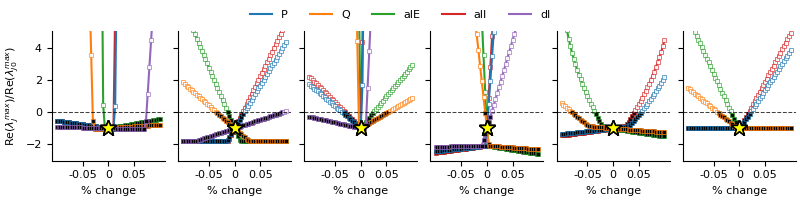

In [156]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

%load_ext autoreload
%autoreload 2
%matplotlib widget

plt.rcParams.update({'font.size': 8})
plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# ── How many parameters to show per subject (smallest instability threshold) ──
num_parameters_to_plot = 5

# ── Parameters to exclude per subject (subject_id -> list of param names) ──
# Example: {'100307': ['aEE', 'sII'], '133019': ['dE']}
parameters_to_exclude = {'100307': ['aDWII']}

# ── Global parameters to exclude from all subjects ──
global_parameters_to_exclude = []

# ═══════════════════════════════════════════════════════════════════════════════
# Determine which parameters will actually appear in each panel,
# so colors/markers are assigned only to the plotted set
# ═══════════════════════════════════════════════════════════════════════════════
parameters_to_plot_per_subject = {}

for subject_id in subject_ids:
    result = all_subject_stability_results.get(subject_id)
    if result is None:
        parameters_to_plot_per_subject[subject_id] = []
        continue

    scan_results = result['scan_results']
    subject_exclusions = set(global_parameters_to_exclude) | set(parameters_to_exclude.get(subject_id, []))

    # Rank by smallest absolute instability threshold, excluding unwanted parameters
    smallest_threshold_per_parameter = {}
    for param_name in scan_results:
        if param_name in subject_exclusions:
            continue
        parameter_thresholds = [abs(perc) for p, perc in result['all_thresholds'] if p == param_name]
        if parameter_thresholds:
            smallest_threshold_per_parameter[param_name] = min(parameter_thresholds)
        # Parameters without a zero-crossing are not plotted

    parameters_sorted_by_threshold = sorted(smallest_threshold_per_parameter, key=smallest_threshold_per_parameter.get)
    parameters_to_plot_per_subject[subject_id] = parameters_sorted_by_threshold[:num_parameters_to_plot]

# ── Union of all parameters that will actually be plotted ──
all_plotted_parameter_names = sorted(set(
    param
    for params_list in parameters_to_plot_per_subject.values()
    for param in params_list
))

# ── Assign colors + markers to only the plotted set ──
color_cycle = plt.cm.tab10(np.linspace(0, 1, 10)) if len(all_plotted_parameter_names) <= 10 \
    else plt.cm.tab20(np.linspace(0, 1, 20))
marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X', 'h', '<', '>', 'p',
                'd', '8', 'H', '+', 'x', '1', '2', '3', '4', '|']

parameter_style_map = {}
for idx, param_name in enumerate(all_plotted_parameter_names):
    parameter_style_map[param_name] = {
        'color': color_cycle[idx % len(color_cycle)],
        'marker': marker_cycle[idx % len(marker_cycle)],
    }

# ── Create the six-panel figure ──
figure, axes = plt.subplots(1, 6, figsize=(8, 2), sharex=False, sharey=True,
                            constrained_layout=True)

for panel_idx, subject_id in enumerate(subject_ids):
    axis = axes[panel_idx]
    result = all_subject_stability_results.get(subject_id)

    if result is None:
        axis.set_xlabel('% change')
        if panel_idx == 0:
            axis.set_ylabel('Re(λ_max) / |Re(λ_max)₀|')
        continue

    scan_results = result['scan_results']
    parameters_to_plot = parameters_to_plot_per_subject[subject_id]

    # ── Compute the base leading eigenvalue for normalization ──
    first_scan = next(iter(scan_results.values()))
    first_base_idx = np.argmin(np.abs(first_scan['values'] - first_scan['base_value']))
    base_leading_eigenvalue = first_scan['leading_real'][first_base_idx]
    normalization_factor = abs(base_leading_eigenvalue)

    for param_name in parameters_to_plot:
        scan_data = scan_results[param_name]
        values = scan_data['values']
        leading_real = scan_data['leading_real']
        base_value = scan_data['base_value']

        # Convert x-axis to percent change from base
        percent_change_values = (values - base_value) / base_value * 100

        # Normalize y-axis by base eigenvalue magnitude
        normalized_leading_real = leading_real / normalization_factor

        style = parameter_style_map[param_name]
        # Line only (no markers)
        axis.plot(
            percent_change_values, normalized_leading_real,
            color=style['color'],
            linewidth=1.5, label=param_name,
        )
        # Markers with face color: white if Re(λ)>=0, black if <0
        marker_face_colors = np.where(leading_real >= 0, 'w', 'k')
        for i in range(len(percent_change_values)):
            if np.isnan(leading_real[i]):
                continue
            axis.plot(
                percent_change_values[i], normalized_leading_real[i],
                marker='s', markersize=2.5,
                markerfacecolor=marker_face_colors[i], alpha=0.9,
                markeredgecolor=style['color'], markeredgewidth=0.5,
            )

        # Mark the base parameter location
        base_idx = np.argmin(np.abs(values - base_value))
        axis.plot(
            percent_change_values[base_idx], normalized_leading_real[base_idx],
            marker='*', markersize=12, markerfacecolor='yellow',
            markeredgecolor='k', markeredgewidth=1.0, zorder=10,
        )

    axis.axhline(0, color='k', linestyle='--', linewidth=0.75, alpha=0.75)
    axis.set_ylim(-3, 5)
    axis.set_xticks([-0.05,0,0.05],)
    axis.set_xticklabels([-0.05,0,0.05])
    axis.set_xlabel('% change')
    # axis.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=False))
    # axis.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=False))
    if panel_idx == 0:
        axis.set_ylabel('Re($\lambda_J^{max}$)/Re($\lambda_{J0}^{max}$)')

# ── Single legend at the top of the figure ──
legend_handles = {}
for axis in axes:
    handles, labels = axis.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        if label not in legend_handles:
            legend_handles[label] = handle

sorted_legend_labels = [p for p in all_plotted_parameter_names if p in legend_handles]
sorted_legend_handles = [legend_handles[label] for label in sorted_legend_labels]

figure.legend(
    sorted_legend_handles, sorted_legend_labels,
    loc='outside upper center', ncol=len(sorted_legend_labels),
    fontsize=8, frameon=False, #title='Parameter', title_fontsize=6,
)

figure.savefig('all_subjects_stability.pdf', dpi=600, transparent=True, bbox_inches='tight')
plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


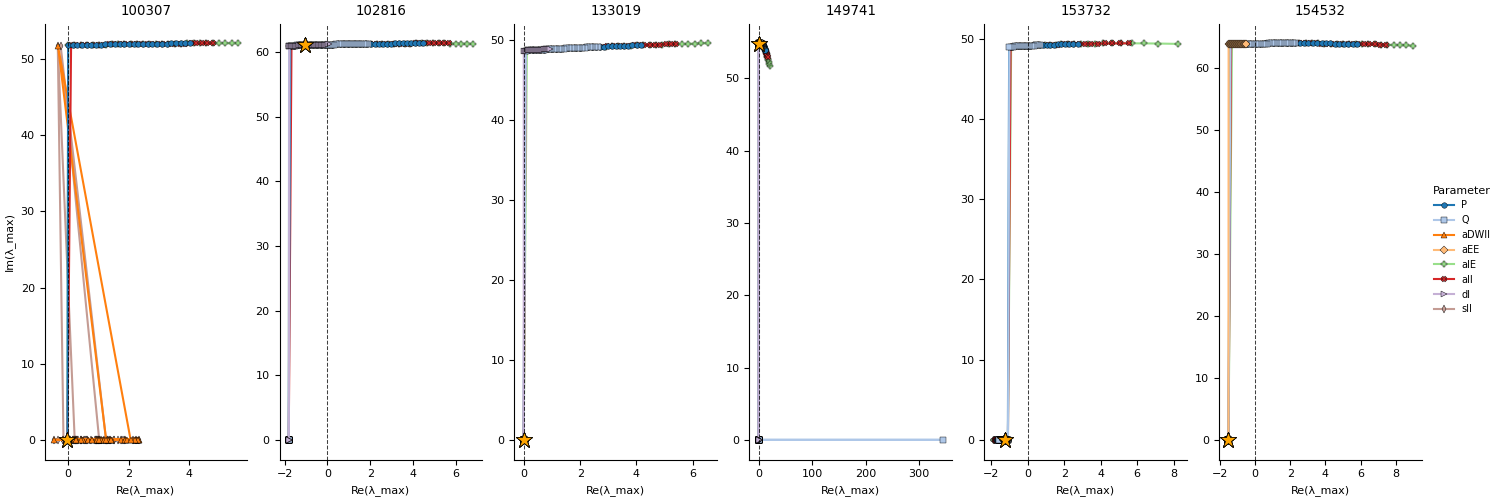

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# %load_ext autoreload
# %autoreload 2
# %matplotlib widget

# plt.rcParams.update({'font.size': 8})
# plt.rcParams.update({'pdf.fonttype': 42})
# plt.rcParams.update({'figure.max_open_warning': 0})
# plt.rcParams['axes.spines.right'] = False
# plt.rcParams['axes.spines.top'] = False

# # ── How many parameters to show per subject (smallest instability threshold) ──
# num_parameters_to_plot = 5

# # ── Optional symmetric log scale on the real-part (x) axis ──
# use_symlog_real_axis = False
# symlog_linthresh = 0.1  # linear region around zero for symlog

# # ── Collect the union of all sensitive parameters across subjects for consistent styling ──
# all_sensitive_parameter_names = sorted(set(
#     param
#     for result in all_subject_stability_results.values()
#     if result is not None
#     for param in result['sensitive_params']
# ))

# # ── Assign a unique color + marker to each parameter ──
# color_cycle = plt.cm.tab20(np.linspace(0, 1, 20))
# marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X', 'h', '<', '>', 'p',
#                 'd', '8', 'H', '+', 'x', '1', '2', '3', '4', '|']

# parameter_style_map = {}
# for idx, param_name in enumerate(all_sensitive_parameter_names):
#     parameter_style_map[param_name] = {
#         'color': color_cycle[idx % len(color_cycle)],
#         'marker': marker_cycle[idx % len(marker_cycle)],
#     }

# # ── Create the six-panel figure ──
# figure, axes = plt.subplots(1, 6, figsize=(15, 5), sharex=False, sharey=False, constrained_layout=True)

# for panel_idx, subject_id in enumerate(subject_ids):
#     axis = axes[panel_idx]
#     result = all_subject_stability_results.get(subject_id)

#     if result is None:
#         axis.set_title(f'{subject_id}\n(no result)')
#         axis.set_xlabel('Re(λ_max)')
#         if panel_idx == 0:
#             axis.set_ylabel('Im(λ_max)')
#         continue

#     base_params = result['base_params']
#     scan_results = result['scan_results']

#     # ── Select the top-N parameters by smallest absolute instability threshold ──
#     # For each scanned parameter, find its smallest |threshold| across all crossings
#     smallest_threshold_per_parameter = {}
#     for param_name in scan_results:
#         # Gather all thresholds for this parameter from all_thresholds
#         parameter_thresholds = [abs(perc) for p, perc in result['all_thresholds'] if p == param_name]
#         if parameter_thresholds:
#             smallest_threshold_per_parameter[param_name] = min(parameter_thresholds)
#         else:
#             # No zero-crossing found: assign infinity so it ranks last
#             smallest_threshold_per_parameter[param_name] = np.inf

#     parameters_sorted_by_threshold = sorted(smallest_threshold_per_parameter, key=smallest_threshold_per_parameter.get)
#     parameters_to_plot = parameters_sorted_by_threshold[:num_parameters_to_plot]

#     for param_name in parameters_to_plot:
#         scan_data = scan_results[param_name]
#         leading_real = scan_data['leading_real']
#         leading_imag = scan_data['leading_imag']
#         values = scan_data['values']
#         base_value = scan_data['base_value']

#         style = parameter_style_map[param_name]
#         axis.plot(
#             leading_real, leading_imag,
#             color=style['color'],
#             marker=style['marker'], markersize=4, markeredgecolor='k', markeredgewidth=0.3,
#             linewidth=1.5, label=param_name,
#         )

#         # Mark the base parameter location
#         base_idx = np.argmin(np.abs(values - base_value))
#         axis.plot(
#             leading_real[base_idx], leading_imag[base_idx],
#             marker='*', markersize=12, markerfacecolor='orange',
#             markeredgecolor='k', markeredgewidth=0.5, zorder=10,
#         )

#     # Stability boundary: vertical line at Re(λ) = 0
#     axis.axvline(0, color='k', linestyle='--', linewidth=0.75, alpha=0.75)

#     if use_symlog_real_axis:
#         axis.set_xscale('symlog', linthresh=symlog_linthresh)

#     #axis.set_yscale('log')
#     axis.set_title(f'{subject_id}')
#     axis.set_xlabel('Re(λ_max)')
#     if panel_idx == 0:
#         axis.set_ylabel('Im(λ_max)')

# # ── Single legend for the whole figure ──
# # Collect unique handles/labels from all axes
# legend_handles = {}
# for axis in axes:
#     handles, labels = axis.get_legend_handles_labels()
#     for handle, label in zip(handles, labels):
#         if label not in legend_handles:
#             legend_handles[label] = handle

# # Sort legend entries to match the global parameter order
# sorted_legend_labels = [p for p in all_sensitive_parameter_names if p in legend_handles]
# sorted_legend_handles = [legend_handles[label] for label in sorted_legend_labels]

# figure.legend(
#     sorted_legend_handles, sorted_legend_labels,
#     loc='outside right', fontsize=7, frameon=False, title='Parameter',
# )

# #figure.savefig('all_subjects_stability.pdf', dpi=600, transparent=True)
# plt.show()